# Support Ticket Classification & Prioritization

## Objective
To build a Machine Learning model that automatically classifies customer support tickets into categories and assigns priority levels to improve support operations.

## Tools Used
- Python
- Pandas
- NumPy
- Scikit-Learn
- Matplotlib

## Machine Learning Model
- Multinomial Naive Bayes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("customer_support_tickets.csv")
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [3]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [27]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
Combined_Text                      0
dtype: int64

In [28]:
print(df['Ticket Type'].value_counts())

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


In [29]:
print(df['Ticket Priority'].value_counts())

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


In [8]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [30]:
df[['Ticket Type','Ticket Subject','Ticket Description']].head(20)

,Ticket Type,Ticket Subject,Ticket Description
0,Technical issue,Product setup,I'm having an issue with the {product_purchase...
1,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...
2,Technical issue,Network problem,I'm facing a problem with my {product_purchase...
3,Billing inquiry,Account access,I'm having an issue with the {product_purchase...
4,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...
5,Cancellation request,Payment issue,I'm facing a problem with my {product_purchase...
6,Product inquiry,Refund request,I'm unable to access my {product_purchased} ac...
7,Refund request,Battery life,I'm having an issue with the {product_purchase...
8,Technical issue,Installation support,I'm having an issue with the {product_purchase...
9,Refund request,Payment issue,My {product_purchased} is making strange noise...


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [11]:
X = df['Ticket Description']
y = df['Ticket Type']

In [31]:
vectorizer = TfidfVectorizer(stop_words='english')
X_tfidf = vectorizer.fit_transform(X)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [34]:
y_pred = model.predict(X_test)

In [35]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 19.13 %


In [36]:
print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

     Billing inquiry       0.16      0.04      0.07       357
Cancellation request       0.18      0.17      0.17       327
     Product inquiry       0.14      0.10      0.12       316
      Refund request       0.20      0.32      0.25       345
     Technical issue       0.22      0.32      0.26       349

            accuracy                           0.19      1694
           macro avg       0.18      0.19      0.17      1694
        weighted avg       0.18      0.19      0.17      1694



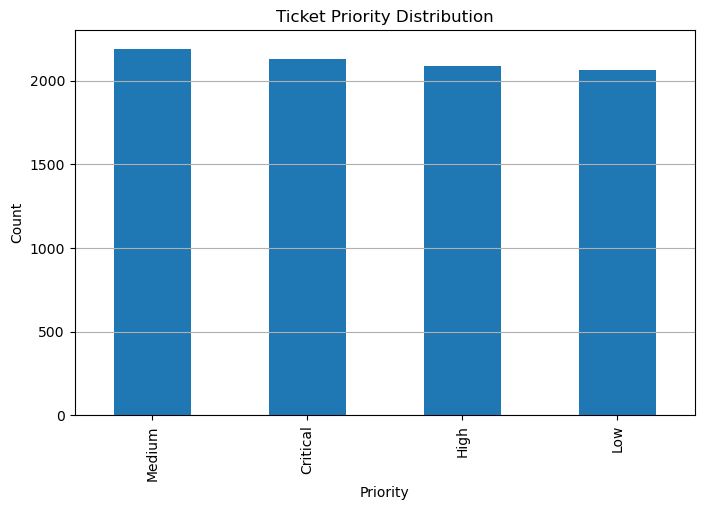

In [38]:
import matplotlib.pyplot as plt

df['Ticket Priority'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Ticket Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.grid(axis='y')

plt.show()

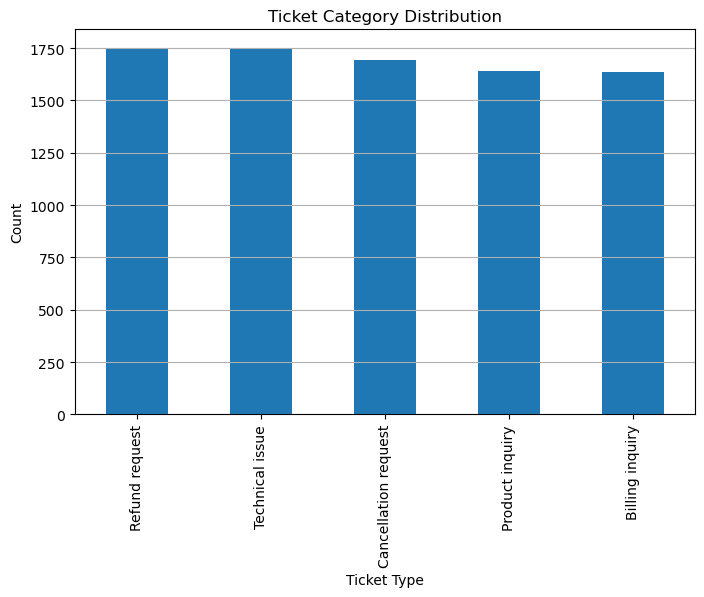

In [40]:
df['Ticket Type'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Ticket Category Distribution")
plt.xlabel("Ticket Type")
plt.ylabel("Count")
plt.grid(axis='y')

plt.show()

## Business Insights

1. The dataset contains five major ticket categories:
   - Technical Issue
   - Billing Inquiry
   - Product Inquiry
   - Refund Request
   - Cancellation Request

2. Ticket priorities are distributed across Critical, High, Medium, and Low levels.

3. TF-IDF was used to convert ticket text into numerical features for Machine Learning.

4. A Multinomial Naive Bayes classifier was trained to automatically categorize support tickets.

5. Automated ticket classification can help reduce manual effort and improve support team efficiency.

6. Priority-based ticket handling allows organizations to respond faster to urgent customer issues.

7. This system can support help-desk teams, SaaS companies, and customer service departments in managing large volumes of tickets.